# CNN + Transfer Learning — Fruit Freshness Classification (Fresh vs Rotten)
## Taller de Redes Neuronales

**Tema:** Clasificación del estado de frescura de frutas mediante Redes Neuronales
Convolucionales (CNN) y Transfer Learning.

> **Nota importante sobre este notebook:** el código que se ejecuta a
> continuación todavía trabaja sobre **CIFAR-10** (10 clases de objetos/animales),
> no sobre el dataset de frutas descrito abajo. Si el objetivo final es el
> problema de "Fresh vs Rotten", falta reemplazar la sección de carga de datos
> (celdas de `torchvision.datasets.CIFAR10`) por la carga del dataset de Kaggle
> de frutas y ajustar `num_classes` y `classes` en consecuencia. Se deja el
> comentario aquí para que quede explícito antes de continuar.

### Introducción
En este trabajo se adapta el pipeline de CNN y Transfer Learning desarrollado
en el taller a un problema de visión por computadora relacionado con la
clasificación de frutas. Se utiliza un dataset de Kaggle que contiene imágenes
de manzanas, plátanos y fresas, clasificadas como *Fresh* o *Rotten*. El
objetivo del modelo será identificar el estado de frescura de la fruta a
partir de su imagen.

### Justificación
Se eligió este problema porque es fácil de interpretar y permite relacionar
la visión por computadora con una aplicación práctica de inspección y control
de calidad de alimentos. Además, al utilizar un dataset externo en lugar de
`medmnist`, fue necesario adaptar el pipeline trabajado en clase al nuevo
conjunto de imágenes y construir el proceso de preparación de datos para
PyTorch.

Este dataset también permite experimentar con los diferentes aspectos
planteados en el taller, como cambios en la arquitectura, learning rate,
scheduler, data augmentation y Transfer Learning con ResNet18.

### Objetivo
Desarrollar y evaluar modelos de CNN para clasificar imágenes de frutas como
*Fresh* o *Rotten*, analizando cómo diferentes configuraciones de
entrenamiento y Transfer Learning afectan su desempeño.

### Ejercicios desarrollados
1. Cambiar la arquitectura de la CNN mediante BatchNorm, Dropout y más filtros.
2. Experimentar con learning rate y scheduler.
3. Analizar el impacto del data augmentation.
4. La guía propone cambiar el dataset dentro de `medmnist`. En este trabajo,
   el cambio se realizó desde el inicio utilizando un dataset no médico
   descargado desde Kaggle, con imágenes de frutas clasificadas como *Fresh*
   y *Rotten*. Por ello, todo el pipeline se adapta a este nuevo dataset y el
   objetivo del ejercicio queda cubierto sin utilizar un segundo dataset.
5. Implementar calibración de probabilidades y curvas ROC.

### 1. ¿Qué es una CNN y por qué se usa en este problema?
Una CNN es un tipo de red neuronal diseñada para trabajar con datos que
tienen estructura espacial, como imágenes. En una imagen, los píxeles
cercanos suelen estar relacionados (bordes, texturas, formas); las CNN
explotan esta propiedad mediante convoluciones, filtros aprendibles que se
deslizan por la imagen para detectar patrones.

**Componentes clave**

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas
  profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- `ReLU(x) = max(0, x)` suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para la clasificación final (Fresh / Rotten).

**1.2. ¿Por qué CNN para este problema?**
La frescura de una fruta se refleja en patrones visuales sutiles (manchas,
cambios de textura y color, arrugas en la cáscara). Una CNN puede aprender
estas representaciones de forma jerárquica sin tener que diseñar
manualmente reglas de color o textura. Además, con transfer learning
(ResNet18 preentrenada en ImageNet) se puede aprovechar conocimiento visual
general para mejorar el desempeño con un dataset relativamente pequeño
(522 imágenes únicas).


## Librerías

> Agregar bloque entrecomillado



In [1]:
# --- Librerías ---
import os                          # utilidades del sistema operativo (crear carpetas, rutas, etc.)
import random                      # generador de números aleatorios de Python (para fijar semillas)
import numpy as np                 # operaciones numéricas / arreglos
import matplotlib.pyplot as plt    # gráficos (curvas, matrices de confusión, imágenes)

import torch                       # framework de deep learning
import torch.nn as nn              # módulos para construir redes neuronales (capas, funciones de pérdida)
import torchvision                 # datasets, modelos y transformaciones para visión por computadora
import torchvision.transforms as T # transformaciones de imágenes (resize, normalización, augmentation)
import torchvision.models as models  # modelos preentrenados (aquí usaremos ResNet18)

from torch.utils.data import DataLoader, Subset
# DataLoader: entrega los datos en lotes (batches) durante el entrenamiento
# Subset: permite tomar un subconjunto de un dataset ya existente (sin copiar los datos)

from sklearn.metrics import (
    accuracy_score,         # exactitud (proporción de aciertos)
    roc_auc_score,          # área bajo la curva ROC, mide qué tan bien se separan las clases
    classification_report,  # reporte con precision, recall y f1-score por clase
    confusion_matrix        # matriz de confusión (aciertos y errores por clase)
)

# Verificamos las versiones instaladas, útil para reproducibilidad
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu


## Reproducibilidad
Esto es importante porque vamos a seleccionar solamente una parte de CIFAR-10

In [2]:
# Fijamos una semilla (seed) para que los resultados sean reproducibles:
# si volvemos a correr el notebook, obtendremos la misma selección de datos,
# la misma inicialización de pesos, etc.
SEED = 42

random.seed(SEED)          # semilla para el módulo random de Python
np.random.seed(SEED)       # semilla para NumPy
torch.manual_seed(SEED)    # semilla para PyTorch (CPU)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # semilla también para todas las GPUs disponibles

print("Seed:", SEED)

Seed: 42


## Configuración del dispositivo

In [18]:
# Seleccionamos el dispositivo de cómputo: GPU (cuda) si está disponible,
# de lo contrario usamos CPU. Todo el entrenamiento se hará en este dispositivo.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

Dispositivo: cpu


## Clases de CIFAR-10

In [19]:
# Nombres de las 10 clases de CIFAR-10, en el mismo orden en que
# el dataset las codifica internamente (0 = avión, 1 = automóvil, ...).
classes = [
    "avión",
    "automóvil",
    "pájaro",
    "gato",
    "ciervo",
    "perro",
    "rana",
    "caballo",
    "barco",
    "camión"
]

num_classes = len(classes)   # número total de clases (10)

print("Número de clases:", num_classes)
print(classes)

Número de clases: 10
['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']


## Transformación básica

In [20]:
# Transformación mínima: solo convierte la imagen (PIL) a tensor de PyTorch
# y escala los valores de píxeles al rango [0, 1].
transform_basic = T.Compose([
    T.ToTensor()
])

## Descargar CIFAR-10

In [21]:
# Descargamos (o cargamos si ya existen localmente) los conjuntos
# de entrenamiento y prueba de CIFAR-10, aplicando la transformación básica.
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform_basic,
    download=True
)

full_test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform_basic,
    download=True
)

print("Dataset original de entrenamiento:", len(full_train_dataset))
print("Dataset original de prueba:", len(full_test_dataset))

100%|██████████| 170M/170M [30:45<00:00, 92.4kB/s]


Dataset original de entrenamiento: 50000
Dataset original de prueba: 10000


## Crear nuestro dataset reducido

In [22]:
# Generador con semilla propia para que el orden aleatorio sea reproducible.
g = torch.Generator().manual_seed(SEED)

# Tomamos un subconjunto aleatorio de 15 000 índices de entrenamiento
# (de los 50 000 originales de CIFAR-10) para acelerar el entrenamiento.
train_indices = torch.randperm(
    len(full_train_dataset),
    generator=g
)[:15000]

# Tomamos 3000 índices aleatorios del conjunto de prueba original.
test_indices = torch.randperm(
    len(full_test_dataset),
    generator=g
)[:3000]

Ahora dividimos los 15 000 de entrenamiento:

In [23]:
# Intento inicial de separar los 15 000 índices en train/val.
# OJO: aquí hay un error (se corrige en la celda siguiente): al generar
# val_indices con un nuevo randperm(15000), los valores obtenidos son
# posiciones dentro del subconjunto de 15 000, no índices reales del
# dataset original de CIFAR-10 (full_train_dataset).
train_indices = train_indices[:12000]
val_indices = train_indices.new_tensor(
    torch.randperm(15000, generator=g)[:3000]
)

/tmp/ipykernel_1247/4049844427.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  val_indices = train_indices.new_tensor(


quí hay un problema: val_indices estaría haciendo referencia a posiciones del subconjunto, no directamente al dataset original.

Corrijamos

In [24]:
# Versión corregida: generamos de nuevo, con la MISMA semilla, los 15 000
# índices sobre el dataset completo y los partimos directamente en:
#   - 12 000 para entrenamiento
#   - 3 000 para validación
# De esta forma, train_indices y val_indices sí son índices válidos
# de full_train_dataset (sin solaparse entre ellos).
g = torch.Generator().manual_seed(SEED)

all_train_indices = torch.randperm(
    len(full_train_dataset),
    generator=g
)[:15000]

train_indices = all_train_indices[:12000]   # primeros 12 000 -> entrenamiento
val_indices = all_train_indices[12000:]     # últimos 3 000   -> validación

# Índices para el conjunto de prueba (independiente del de entrenamiento)
test_indices = torch.randperm(
    len(full_test_dataset),
    generator=g
)[:3000]

In [25]:
# Subset crea "vistas" del dataset original usando solo los índices indicados,
# sin duplicar las imágenes en memoria.
train_dataset = Subset(
    full_train_dataset,
    train_indices
)

val_dataset = Subset(
    full_train_dataset,   # ojo: viene del dataset de TRAIN, no del de test
    val_indices
)

test_dataset = Subset(
    full_test_dataset,
    test_indices
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 12000
Validation: 3000
Test: 3000


# **Visualización**

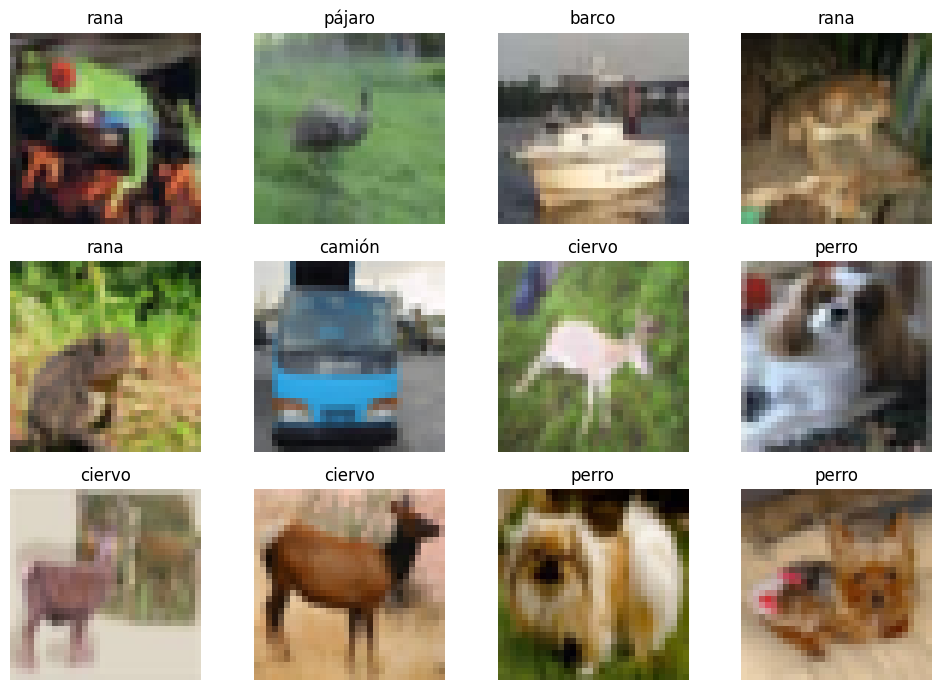

In [26]:
# Función auxiliar para visualizar un lote de imágenes con su etiqueta real.
def show_batch(dataset, n=12):

    plt.figure(figsize=(10, 7))

    for i in range(n):

        x, y = dataset[i]                # x: imagen (tensor), y: etiqueta

        plt.subplot(3, 4, i + 1)         # cuadrícula de 3x4 = 12 imágenes

        img = x.permute(1, 2, 0)         # de (C, H, W) a (H, W, C) para matplotlib

        plt.imshow(img)

        plt.title(classes[int(y)])       # nombre de la clase como título

        plt.axis("off")                  # ocultamos los ejes

    plt.tight_layout()
    plt.show()


show_batch(train_dataset, n=12)   # mostramos 12 imágenes de entrenamiento

# DataLoaders

In [27]:
# Los DataLoaders entregan los datos en lotes (batches) durante el
# entrenamiento/evaluación, y se encargan de barajar (shuffle) y paralelizar
# la carga de datos.
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,                              # barajamos en cada época (solo train)
    num_workers=2,                             # procesos paralelos para cargar datos
    pin_memory=torch.cuda.is_available()       # acelera la transferencia a GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,                             # no es necesario barajar validación
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,                             # tampoco en test
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [28]:
# Tomamos un único lote (batch) del train_loader para verificar las
# dimensiones de las imágenes y las etiquetas.
x_batch, y_batch = next(iter(train_loader))

print("Imágenes:", x_batch.shape)   # esperado: [batch_size, 3, 32, 32]
print("Etiquetas:", y_batch.shape)  # esperado: [batch_size]

Imágenes: torch.Size([128, 3, 32, 32])
Etiquetas: torch.Size([128])


# **CNN desde cero**

In [29]:
# CNN simple construida "desde cero" (sin pesos preentrenados),
# usada como línea base (baseline) para comparar contra versiones mejoradas
# y contra Transfer Learning.
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # Bloque extractor de características (convoluciones + pooling)
        self.features = nn.Sequential(

            # Bloque 1: 3 canales de entrada (RGB) -> 16 mapas de características
            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),           # no linealidad

            nn.MaxPool2d(2),     # reduce a la mitad alto y ancho

            # Bloque 2: 16 -> 32 canales
            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Bloque 3: 32 -> 64 canales
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            # Reduce cada mapa de características a un único valor (1x1),
            # sin importar el tamaño de entrada original.
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Bloque clasificador: convierte las características en logits por clase
        self.classifier = nn.Sequential(

            nn.Flatten(),                 # aplana a un vector

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)     # extracción de características
        x = self.classifier(x)   # clasificación final

        return x

In [30]:
# Instanciamos el modelo y lo movemos al dispositivo (GPU/CPU)
model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

print(model_scratch)   # imprime la arquitectura de la red

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)


## Funciones de entrenamiento y evaluación

In [31]:
# Convierte los logits (salida cruda de la red) en probabilidades
# usando softmax, de modo que las num_classes probabilidades sumen 1.
def logits_to_probs(logits):

    return torch.softmax(
        logits,
        dim=1
    )

In [33]:
# Función de evaluación: recorre un DataLoader completo (sin calcular
# gradientes, gracias a @torch.no_grad()) y devuelve métricas globales.
@torch.no_grad()
def evaluate(model, loader):

    model.eval()   # modo evaluación (desactiva Dropout, fija BatchNorm, etc.)

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        logits = model(x)                 # forward pass

        probs = logits_to_probs(logits)   # logits -> probabilidades

        preds = torch.argmax(
            probs,
            dim=1
        )                                  # clase predicha (la de mayor probabilidad)

        # Acumulamos resultados de cada batch (pasando a CPU/numpy)
        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    # Concatenamos los resultados de todos los batches en un solo arreglo
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(
        y_true,
        y_pred
    )

    # ROC-AUC multiclase: "One vs Rest" promediado de forma macro
    # (le da el mismo peso a cada clase, sin importar su frecuencia)
    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )

In [34]:
# Entrena el modelo durante UNA época completa (una pasada por todo
# el train_loader) y devuelve la pérdida promedio de esa época.
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()   # modo entrenamiento (activa Dropout, BatchNorm en modo batch, etc.)

    losses = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()   # limpiamos gradientes acumulados del paso anterior

        logits = model(x)       # forward pass

        loss = criterion(
            logits,
            y
        )                        # calculamos la pérdida (CrossEntropy)

        loss.backward()         # backpropagation: calcula gradientes

        optimizer.step()        # actualiza los pesos del modelo

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)         # pérdida promedio de la época
    )

## Entrenamiento

In [35]:
# Configuración del entrenamiento: función de pérdida, optimizador
# y diccionario para ir guardando el historial de métricas por época.
criterion = nn.CrossEntropyLoss()   # estándar para clasificación multiclase

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3                          # learning rate inicial
)

epochs = 5

history_scratch = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [36]:
# Bucle principal de entrenamiento del modelo "desde cero"
for epoch in range(1, epochs + 1):

    # Entrenamos una época y obtenemos la pérdida promedio
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    # Evaluamos en el conjunto de validación (sin actualizar pesos)
    val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )

    # Guardamos el historial para poder graficarlo después
    history_scratch["train_loss"].append(
        train_loss
    )

    history_scratch["val_acc"].append(
        val_acc
    )

    history_scratch["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Loss={train_loss:.4f} | "
        f"Accuracy={val_acc:.4f} | "
        f"AUC={val_auc:.4f}"
    )

Epoch 01 | Loss=2.1854 | Accuracy=0.2270 | AUC=0.7179
Epoch 02 | Loss=2.0000 | Accuracy=0.2640 | AUC=0.7597
Epoch 03 | Loss=1.9102 | Accuracy=0.2997 | AUC=0.7777
Epoch 04 | Loss=1.8561 | Accuracy=0.3077 | AUC=0.7872
Epoch 05 | Loss=1.8170 | Accuracy=0.3310 | AUC=0.7954


## Curvas

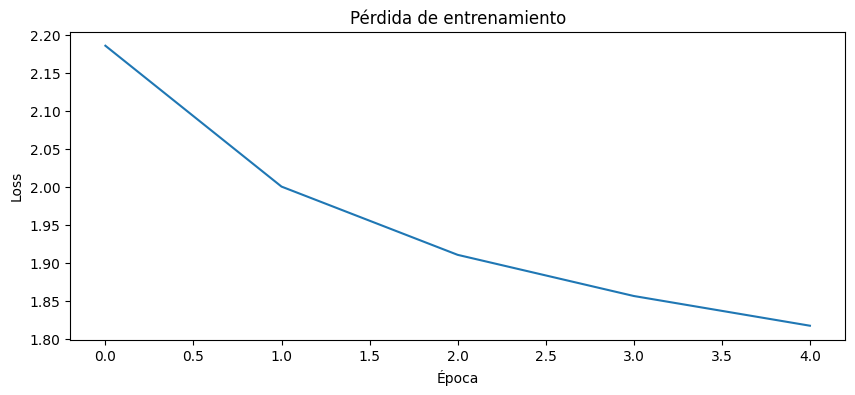

In [37]:
# Graficamos la evolución de la pérdida de entrenamiento por época
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"]
)

plt.title(
    "Pérdida de entrenamiento"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.show()

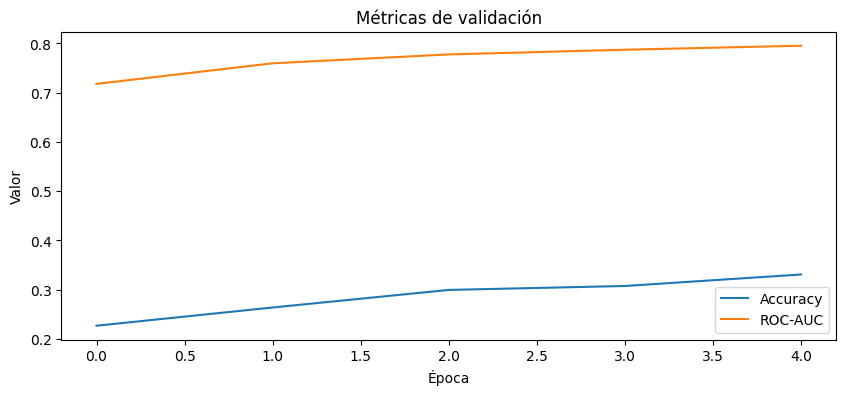

In [38]:
# Graficamos accuracy y AUC de validación por época, para ver
# cómo evoluciona el desempeño del modelo durante el entrenamiento
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_acc"],
    label="Accuracy"
)

plt.plot(
    history_scratch["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()

plt.show()

## Evaluación final

In [39]:
# Evaluación final del modelo "desde cero" sobre el conjunto de TEST
# (datos que el modelo nunca vio durante entrenamiento ni validación)
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch,
    test_loader
)

print(
    f"Test Accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

Test Accuracy: 0.3520
Test ROC-AUC: 0.8122


In [40]:
# Reporte detallado por clase: precision, recall, f1-score y soporte
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4,
        zero_division=0   # evita división por cero si alguna clase no tiene predicciones
    )
)

              precision    recall  f1-score   support

       avión     0.3912    0.3698    0.3802       311
   automóvil     0.4627    0.4769    0.4697       325
      pájaro     0.2830    0.0505    0.0857       297
        gato     0.2465    0.2373    0.2418       295
      ciervo     0.3068    0.3636    0.3328       286
       perro     0.2657    0.3185    0.2897       292
        rana     0.3450    0.4000    0.3705       295
     caballo     0.3684    0.3511    0.3596       319
       barco     0.3960    0.5351    0.4552       299
      camión     0.3864    0.4057    0.3958       281

    accuracy                         0.3520      3000
   macro avg     0.3452    0.3509    0.3381      3000
weighted avg     0.3468    0.3520    0.3396      3000



In [41]:
# Matriz de confusión: filas = clase real, columnas = clase predicha
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[115  24   5   8   1  14   4   9  99  32]
 [  7 155   0  19   0   2   7  14  56  65]
 [ 34   5  15  26  85  56  39  15  17   5]
 [ 16  14   4  70  42  55  37  32  11  14]
 [ 10   7  12  17 104  41  59  27   7   2]
 [ 19   9   5  56  35  93  37  29   3   6]
 [  2   9   2  23  50  41 118  40   0  10]
 [ 15   9   3  44  22  38  34 112  11  31]
 [ 64  33   4   8   0   9   1   4 160  16]
 [ 12  70   3  13   0   1   6  22  40 114]]


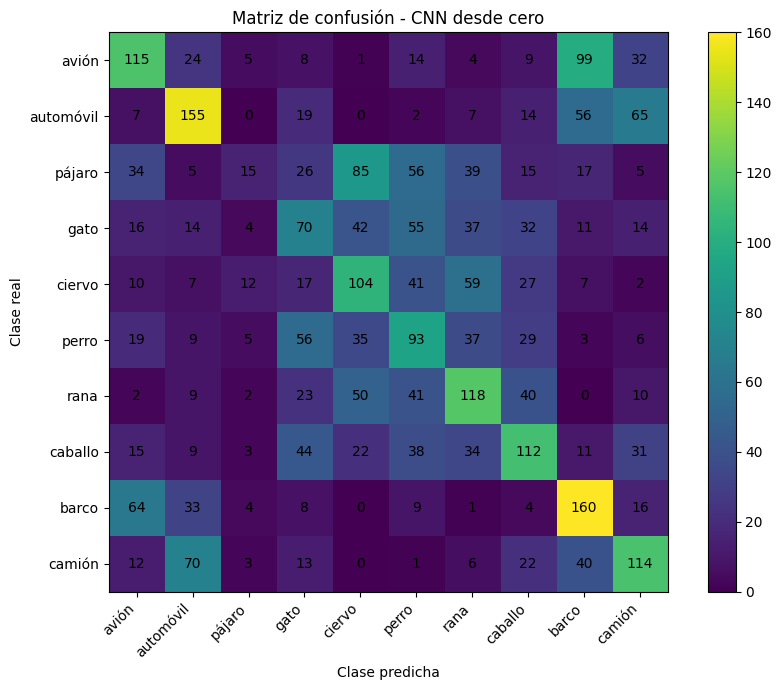

In [42]:
# Visualización de la matriz de confusión como mapa de calor
plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Matriz de confusión - CNN desde cero")
plt.colorbar()

plt.xticks(
    range(num_classes),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_classes),
    classes
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

# Mostrar los valores dentro de cada celda
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# Data Augmentation

In [43]:
# Transformaciones de data augmentation: se aplican SOLO al conjunto
# de entrenamiento, para generar variaciones artificiales de las imágenes
# y ayudar al modelo a generalizar mejor.
transform_aug = T.Compose([

    T.RandomHorizontalFlip(),        # voltea la imagen horizontalmente al azar

    T.RandomRotation(
        degrees=10                    # rota la imagen hasta +/-10 grados
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)        # pequeños desplazamientos horizontales/verticales
    ),

    T.ToTensor()
])

In [44]:
# Volvemos a cargar CIFAR-10, esta vez con las transformaciones de
# augmentation, y construimos el mismo subconjunto de entrenamiento
# (mismos índices) pero con imágenes aumentadas.
full_train_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform_aug,
    download=True
)

train_dataset_aug = Subset(
    full_train_aug,
    train_indices
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

Modelo:

In [45]:
# Nuevo modelo (misma arquitectura SimpleCNN) que se entrenará
# usando el train_loader con data augmentation
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

Entrenamiento:

In [46]:
# NOTA: esta celda reinicializa el modelo y el optimizador de nuevo,
# de forma idéntica a la celda anterior (parece una celda duplicada).
# Aquí debería ir, en su lugar, el bucle de entrenamiento con
# train_loader_aug (equivalente al de la CNN "desde cero" pero
# usando los datos con augmentation).
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

Evaluacion:

In [47]:
# Evaluación del modelo entrenado con data augmentation sobre TEST
test_acc_aug, test_auc_aug, y_true_aug, y_pred_aug, y_prob_aug = evaluate(
    model_aug,
    test_loader
)

print(
    f"Con augmentation | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)

Con augmentation | test_acc=0.0953 | test_auc=0.4636


# **Transfer Learning**

In [48]:
# Transformaciones para Transfer Learning (entrenamiento):
# ResNet18 espera imágenes de 224x224 y normalizadas con las
# estadísticas (media/desviación estándar) de ImageNet, dataset con
# el que fue preentrenada.
transform_tl_train = T.Compose([

    T.Resize((224, 224)),          # redimensiona de 32x32 (CIFAR) a 224x224

    T.RandomHorizontalFlip(),      # augmentation: flip horizontal

    T.RandomRotation(
        degrees=10                 # augmentation: rotación leve
    ),

    T.ToTensor(),

    T.Normalize(
        mean=[0.485, 0.456, 0.406],   # medias por canal (RGB) de ImageNet
        std=[0.229, 0.224, 0.225]     # desviaciones estándar por canal de ImageNet
    )
])

Evaluacion:

In [49]:
# Transformaciones para validación/test: igual que en entrenamiento
# pero SIN augmentation (solo resize, tensor y normalización), ya que
# en evaluación queremos ver el rendimiento sobre imágenes "reales",
# no aumentadas artificialmente.
transform_tl_eval = T.Compose([

    T.Resize((224, 224)),

    T.ToTensor(),

    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

DataSets:

In [50]:
# Construimos los datasets para Transfer Learning, reutilizando los
# mismos índices (train_indices, val_indices, test_indices) que en el
# resto del notebook, pero con las transformaciones adaptadas a ResNet18.
train_dataset_tl = Subset(
    torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        transform=transform_tl_train,   # con augmentation
        download=True
    ),
    train_indices
)

val_dataset_tl = Subset(
    torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        transform=transform_tl_eval,    # sin augmentation
        download=True
    ),
    val_indices
)

test_dataset_tl = Subset(
    torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        transform=transform_tl_eval,    # sin augmentation
        download=True
    ),
    test_indices
)

Loaders:

In [51]:
# DataLoaders para Transfer Learning. Usamos batch_size=64 (más chico
# que antes) porque las imágenes ahora son 224x224 y consumen más memoria.
train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [52]:
# Verificamos la forma de un batch: debería ser [64, 3, 224, 224]
next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

## RestNet18

In [53]:
# Cargamos ResNet18 preentrenada en ImageNet (pesos por defecto)
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Guardamos el número de features de entrada de la última capa original
in_features = resnet.fc.in_features

# Reemplazamos la última capa (fc) de ResNet18 (pensada para 1000 clases
# de ImageNet) por una nueva capa lineal adaptada a nuestro número de clases
resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


Congelamos backtone

In [54]:
# Congelamos TODO el backbone de ResNet18 (no se actualizan sus pesos
# durante el entrenamiento), y solo dejamos entrenable la nueva capa
# final (fc). Así aprovechamos las características ya aprendidas por
# ResNet18 en ImageNet, entrenando únicamente el clasificador nuevo.
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True


## Entrenamiento inicial

In [55]:
# Etapa 1 de Transfer Learning ("feature extraction"): solo se
# entrena la capa final (fc), el resto de la red permanece congelado.
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),   # OJO: solo optimizamos los parámetros de fc
    lr=1e-3
)

epochs = 3

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(
        train_loss
    )

    history_tl_stage1["val_acc"].append(
        val_acc
    )

    history_tl_stage1["val_auc"].append(
        val_auc
    )

    print(
        f"Stage 1 | Epoch {epoch:02d} | "
        f"Loss={train_loss:.4f} | "
        f"Accuracy={val_acc:.4f} | "
        f"AUC={val_auc:.4f}"
    )

Stage 1 | Epoch 01 | Loss=1.3426 | Accuracy=0.7217 | AUC=0.9656
Stage 1 | Epoch 02 | Loss=0.8876 | Accuracy=0.7463 | AUC=0.9712
Stage 1 | Epoch 03 | Loss=0.7829 | Accuracy=0.7520 | AUC=0.9735


## Fine-tuning

In [56]:
# Etapa 2: fine-tuning parcial. Además de la capa fc, "descongelamos"
# también el último bloque convolucional de ResNet18 (layer4), que
# contiene las características más específicas/abstractas, para
# adaptarlas mejor a nuestro dataset.
for name, param in resnet.named_parameters():

    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

# Lista de todos los parámetros que sí se van a entrenar en esta etapa
trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

print(
    "Parámetros entrenables:",
    len(trainable_params)
)

Parámetros entrenables: 17


In [ ]:
# Entrenamos la segunda etapa con un learning rate más bajo (1e-4),
# típico en fine-tuning, para no destruir el conocimiento preentrenado.
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 3

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(
        train_loss
    )

    history_tl_stage2["val_acc"].append(
        val_acc
    )

    history_tl_stage2["val_auc"].append(
        val_auc
    )

    print(
        f"Stage 2 | Epoch {epoch:02d} | "
        f"Loss={train_loss:.4f} | "
        f"Accuracy={val_acc:.4f} | "
        f"AUC={val_auc:.4f}"
    )

## Evaluación

In [ ]:
# Evaluación final de ResNet18 (Transfer Learning) sobre el conjunto de TEST
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer Learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

In [ ]:
# Reporte de clasificación por clase para el modelo de Transfer Learning
print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

In [ ]:
# Matriz de confusión del modelo de Transfer Learning
cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

print(cm_tl)

## Comparación

In [ ]:
# Comparación resumida de los 3 enfoques probados hasta este punto:
# CNN desde cero, CNN con augmentation, y ResNet18 con Transfer Learning
print("Resumen de resultados")
print("----------------------------------------")

print(
    f"CNN desde cero | "
    f"acc={test_acc:.4f} | "
    f"auc={test_auc:.4f}"
)

print(
    f"CNN + augmentation | "
    f"acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f}"
)

print(
    f"ResNet18 Transfer Learning | "
    f"acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f}"
)


# Grad-CAM

In [ ]:
# Grad-CAM: técnica de interpretabilidad que resalta qué zonas de la
# imagen fueron más importantes para que la red llegara a su predicción.
# Funciona combinando los mapas de activación de una capa convolucional
# con los gradientes de la clase predicha respecto a esos mapas.
def grad_cam(
    model,
    image_tensor,
    target_class=None
):

    model.eval()

    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    # Hook que guarda la salida (activaciones) de la capa elegida
    def forward_hook(module, inp, out):

        activations["value"] = out

    # Hook que guarda el gradiente que llega a esa misma capa
    def backward_hook(module, grad_in, grad_out):

        gradients["value"] = grad_out[0]

    # Registramos los hooks sobre la última capa convolucional de ResNet18
    handle_fwd = (
        model.layer4.register_forward_hook(
            forward_hook
        )
    )

    handle_bwd = (
        model.layer4.register_full_backward_hook(
            backward_hook
        )
    )

    # Forward pass con una sola imagen (unsqueeze agrega la dimensión de batch)
    logits = model(
        image_tensor.unsqueeze(0)
    )

    # Si no se especifica una clase, usamos la predicha por el modelo
    if target_class is None:

        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    model.zero_grad()

    score.backward()   # backward solo hasta la clase de interés

    act = activations["value"][0]     # activaciones de layer4 para esta imagen
    grad = gradients["value"][0]      # gradientes de esa misma capa

    # Promediamos los gradientes espacialmente para obtener un peso por canal
    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    # Combinación ponderada de los mapas de activación según su importancia
    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)      # solo nos interesa la contribución positiva

    # Normalizamos el mapa de calor entre 0 y 1 para poder visualizarlo
    cam = (
        cam - cam.min()
    )

    cam = cam / (
        cam.max() + 1e-8       # +1e-8 evita división por cero
    )

    # Quitamos los hooks para no dejarlos activos en usos futuros del modelo
    handle_fwd.remove()
    handle_bwd.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )

Desnormalizamos las imagenes

In [ ]:
# Guardamos media y desviación estándar de ImageNet para poder
# "desnormalizar" las imágenes antes de visualizarlas (ya que fueron
# normalizadas con estos mismos valores en transform_tl_eval).
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

Tomamos una imagen

In [ ]:
# Tomamos la primera imagen del conjunto de test (ya transformada
# para ResNet18) y calculamos su mapa de Grad-CAM
x, y = test_dataset_tl[0]

cam, predicted_class = grad_cam(
    resnet,
    x
)

Visualizar

In [ ]:
# NOTA: esta celda repite exactamente el cálculo de la celda anterior.
# Aquí normalmente iría el código para VISUALIZAR el resultado: superponer
# el mapa "cam" (redimensionado al tamaño de la imagen) sobre la imagen
# original desnormalizada, usando por ejemplo plt.imshow(img) seguido de
# plt.imshow(cam, cmap="jet", alpha=0.5).
x, y = test_dataset_tl[0]

cam, predicted_class = grad_cam(
    resnet,
    x
)

# Buenas prácticas

##  Buenas prácticas

1. Separar estrictamente los conjuntos de entrenamiento,
   validación y prueba.

2. Utilizar una semilla para garantizar reproducibilidad.

3. Reportar métricas más allá de Accuracy:
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Matriz de confusión

4. Evitar data leakage entre los conjuntos.

5. Comparar los modelos bajo condiciones similares.

6. Utilizar data augmentation únicamente sobre entrenamiento.

7. Utilizar técnicas de interpretabilidad como Grad-CAM,
   teniendo en cuenta que una visualización no demuestra causalidad.

8. Registrar:
   - arquitectura,
   - hiperparámetros,
   - número de épocas,
   - dataset utilizado,
   - semilla,
   - versión de las librerías.

9. Guardar los modelos entrenados para permitir su reutilización.

# Guardado de modelos

In [ ]:
# Creamos (si no existe ya) la carpeta donde se guardarán los modelos entrenados
os.makedirs(
    "models",
    exist_ok=True
)

In [ ]:
# Guardamos los pesos (state_dict) de los 3 modelos entrenados hasta
# este punto, para poder reutilizarlos sin tener que reentrenar desde cero.
torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer.pth"
)

print("Modelos guardados correctamente.")

# **_Ejercicio 1 — Mejorar la arquitectura de la CNN_**

In [ ]:
# Ejercicio 1: CNN mejorada respecto a SimpleCNN, agregando:
#  - BatchNorm2d: normaliza las activaciones de cada capa, estabiliza y
#    acelera el entrenamiento.
#  - Dropout: apaga aleatoriamente un porcentaje de neuronas durante el
#    entrenamiento, reduciendo el sobreajuste (overfitting).
#  - Más filtros por capa (32 -> 64 -> 128 en vez de 16 -> 32 -> 64),
#    permitiendo aprender representaciones más ricas.
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),      # normaliza la salida de la convolución
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),        # apaga el 20% de las activaciones al azar

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),        # apaga el 25% de las activaciones al azar

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),        # dropout adicional antes de la capa final
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

la red puede aprender representaciones más complejas.

**BatchNorm**

In [ ]:
# BatchNorm2d normaliza las activaciones de cada canal dentro de un
# batch (media 0, varianza 1) y luego las reescala con parámetros
# aprendibles. Ayuda a que el entrenamiento sea más estable y rápido.
nn.BatchNorm2d(...)

**Dropout**

In [ ]:
# Dropout apaga aleatoriamente un porcentaje de neuronas en cada paso
# de entrenamiento, forzando a la red a no depender de neuronas
# específicas y así reducir el sobreajuste (overfitting).
nn.Dropout(...)

# Crear y entrenar la nueva CNN

In [ ]:
# Instanciamos la CNN mejorada y su optimizador
model_improved = ImprovedCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_improved = torch.optim.Adam(
    model_improved.parameters(),
    lr=1e-3
)

In [ ]:
# Entrenamiento de la CNN mejorada, igual que con el modelo original,
# pero usando model_improved y optimizer_improved
epochs = 5

history_improved = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_improved,
        train_loader,
        optimizer_improved,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_improved,
        val_loader
    )

    history_improved["train_loss"].append(train_loss)
    history_improved["val_acc"].append(val_acc)
    history_improved["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss={train_loss:.4f} | "
        f"Accuracy={val_acc:.4f} | "
        f"AUC={val_auc:.4f}"
    )

# **Evaluar en test**

In [ ]:
# Evaluación de la CNN mejorada sobre el conjunto de TEST
test_acc_improved, test_auc_improved, \
y_true_improved, y_pred_improved, y_prob_improved = evaluate(
    model_improved,
    test_loader
)

print(
    f"CNN mejorada | "
    f"Accuracy={test_acc_improved:.4f} | "
    f"ROC-AUC={test_auc_improved:.4f}"
)

**Reporte**

In [ ]:
# Reporte de clasificación de la CNN mejorada
print(
    classification_report(
        y_true_improved,
        y_pred_improved,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

**Matriz de confusion**

In [ ]:
# Matriz de confusión de la CNN mejorada
cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved
)

print(cm_improved)

In [ ]:
# Visualización de la matriz de confusión de la CNN mejorada
plt.figure(figsize=(9, 7))

plt.imshow(
    cm_improved,
    interpolation="nearest"
)

plt.title("Matriz de confusión - CNN mejorada")
plt.colorbar()

plt.xticks(
    range(num_classes),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_classes),
    classes
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            cm_improved[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**Comparamos**

In [ ]:
# Comparamos numéricamente la CNN original contra la CNN mejorada
print("Comparación de modelos")
print("----------------------------------------")

print(
    f"CNN original     | "
    f"Accuracy={test_acc:.4f} | "
    f"AUC={test_auc:.4f}"
)

print(
    f"CNN mejorada     | "
    f"Accuracy={test_acc_improved:.4f} | "
    f"AUC={test_auc_improved:.4f}"
)

In [ ]:
# Comparamos también las matrices de confusión completas de ambos modelos
print("Matriz CNN original:")
print(cm)

print("\nMatriz CNN mejorada:")
print(cm_improved)

**guardamos modelo**

In [ ]:
# Guardamos los pesos de la CNN mejorada
os.makedirs("models", exist_ok=True)

torch.save(
    model_improved.state_dict(),
    "models/cnn_improved.pth"
)

print("Modelo guardado correctamente.")

**_Ejercicio 2 — Learning Rate y Scheduler_**

## Función para realizar un experimento

In [ ]:
# Ejercicio 2: función reutilizable para correr un experimento completo
# variando el learning rate y, opcionalmente, usando un scheduler.
def run_lr_experiment(lr, epochs=5, scheduler_type=None):

    # Cada experimento parte de un modelo nuevo (mismos pesos iniciales
    # gracias a la semilla global fijada al inicio del notebook)
    model = SimpleCNN(
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = None

    # Scheduler tipo "step": cada 2 épocas multiplica el LR por 0.5,
    # es decir, lo va reduciendo progresivamente durante el entrenamiento
    if scheduler_type == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=2,
            gamma=0.5
        )

    history = {
        "train_loss": [],
        "val_acc": [],
        "val_auc": [],
        "lr": []          # guardamos también el LR usado en cada época
    }

    for epoch in range(1, epochs + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_acc, val_auc, _, _, _ = evaluate(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        history["lr"].append(
            optimizer.param_groups[0]["lr"]   # LR actual del optimizador
        )

        print(
            f"Epoch {epoch:02d} | "
            f"LR={optimizer.param_groups[0]['lr']:.6f} | "
            f"Loss={train_loss:.4f} | "
            f"Accuracy={val_acc:.4f} | "
            f"AUC={val_auc:.4f}"
        )

        # El scheduler actualiza el LR AL FINAL de cada época
        if scheduler is not None:
            scheduler.step()

    # Evaluación final en test, una vez terminado el entrenamiento
    test_acc, test_auc, _, _, _ = evaluate(
        model,
        test_loader
    )

    return model, history, test_acc, test_auc

## Experimento con lr = 0.01

In [ ]:
# Experimento con un learning rate alto (1e-2): puede converger rápido
# pero también puede ser inestable o no converger bien
model_lr_01, history_lr_01, acc_lr_01, auc_lr_01 = run_lr_experiment(
    lr=1e-2,
    epochs=5
)

print(
    f"\nLR=1e-2 | "
    f"Test Accuracy={acc_lr_01:.4f} | "
    f"Test AUC={auc_lr_01:.4f}"
)

## Experimento con lr = 0.001

In [ ]:
# Experimento con learning rate "intermedio" (1e-3), el mismo usado
# como valor por defecto en el resto del notebook
model_lr_001, history_lr_001, acc_lr_001, auc_lr_001 = run_lr_experiment(
    lr=1e-3,
    epochs=5
)

print(
    f"\nLR=1e-3 | "
    f"Test Accuracy={acc_lr_001:.4f} | "
    f"Test AUC={auc_lr_001:.4f}"
)

## Experimento con lr = 0.0001

In [ ]:
# Experimento con learning rate bajo (1e-4): entrenamiento más lento
# pero potencialmente más estable
model_lr_0001, history_lr_0001, acc_lr_0001, auc_lr_0001 = run_lr_experiment(
    lr=1e-4,
    epochs=5
)

print(
    f"\nLR=1e-4 | "
    f"Test Accuracy={acc_lr_0001:.4f} | "
    f"Test AUC={auc_lr_0001:.4f}"
)

Learning Rate + Scheduler

In [ ]:
# Experimento combinando un LR inicial moderado (1e-3) con el
# scheduler "step", que lo reduce a la mitad cada 2 épocas
model_scheduler, history_scheduler, acc_scheduler, auc_scheduler = run_lr_experiment(
    lr=1e-3,
    epochs=5,
    scheduler_type="step"
)

print(
    f"\nScheduler | "
    f"Test Accuracy={acc_scheduler:.4f} | "
    f"Test AUC={auc_scheduler:.4f}"
)